In [1]:
from google.colab import files
uploaded=files.upload()

Saving country_wise_latest.csv to country_wise_latest.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("country_wise_latest.csv")

In [4]:
print("First 5 rows:")
print(data.head())


First 5 rows:
  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526         

In [5]:
print("\nColumns in dataset:")
print(data.columns)



Columns in dataset:
Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')


In [6]:
data = data.rename(columns={
    "Country/Region": "Country",
    "ObservationDate": "Date"
})


In [7]:
cols = ["Date", "Country", "Confirmed", "Deaths", "Recovered", "Active"]
data = data[[col for col in cols if col in data.columns]]

In [8]:
if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"])


In [9]:
data = data.dropna()


In [10]:
data = data.drop_duplicates()


In [11]:
print("\nCleaned Data Info:")
print(data.info())



Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    187 non-null    object
 1   Confirmed  187 non-null    int64 
 2   Deaths     187 non-null    int64 
 3   Recovered  187 non-null    int64 
 4   Active     187 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.4+ KB
None


In [12]:
print("\nTotal Confirmed Cases:", data["Confirmed"].sum())
print("Total Deaths:", data["Deaths"].sum())
print("Total Recovered:", data["Recovered"].sum())


Total Confirmed Cases: 16480485
Total Deaths: 654036
Total Recovered: 9468087


In [13]:
print("\nStatistical Summary:")
print(data.describe())



Statistical Summary:
          Confirmed         Deaths     Recovered        Active
count  1.870000e+02     187.000000  1.870000e+02  1.870000e+02
mean   8.813094e+04    3497.518717  5.063148e+04  3.400194e+04
std    3.833187e+05   14100.002482  1.901882e+05  2.133262e+05
min    1.000000e+01       0.000000  0.000000e+00  0.000000e+00
25%    1.114000e+03      18.500000  6.265000e+02  1.415000e+02
50%    5.059000e+03     108.000000  2.815000e+03  1.600000e+03
75%    4.046050e+04     734.000000  2.260600e+04  9.149000e+03
max    4.290259e+06  148011.000000  1.846641e+06  2.816444e+06


In [14]:
top_countries = data.groupby("Country")["Confirmed"].sum().sort_values(ascending=False).head(10)

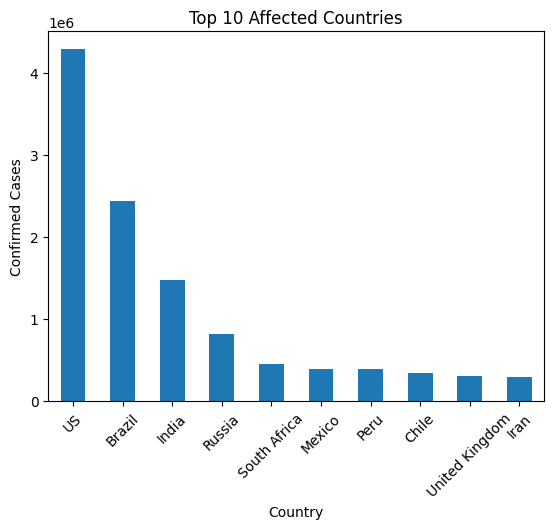

In [15]:
plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 10 Affected Countries")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()


In [16]:
totals = data[["Confirmed", "Deaths", "Recovered"]].sum()

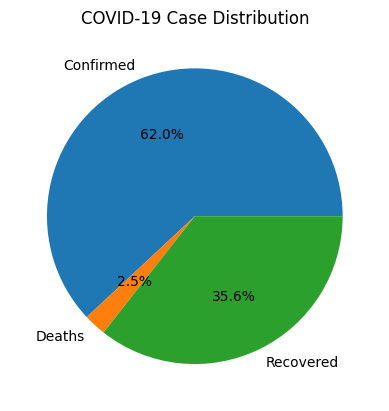

In [17]:
plt.figure()
totals.plot(kind="pie", autopct="%1.1f%%")
plt.title("COVID-19 Case Distribution")
plt.ylabel("")
plt.show()


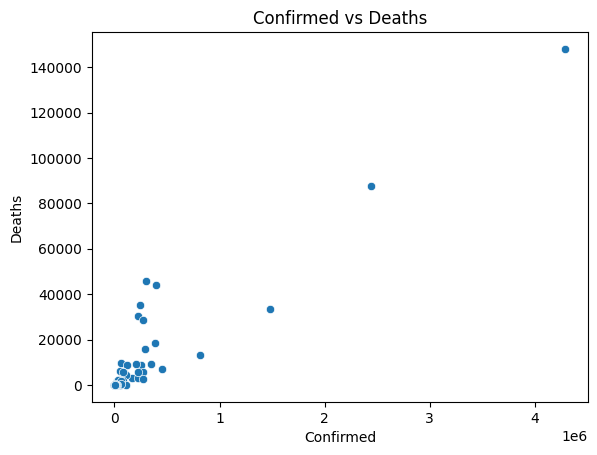

In [18]:
plt.figure()
sns.scatterplot(x="Confirmed", y="Deaths", data=data)
plt.title("Confirmed vs Deaths")
plt.show()


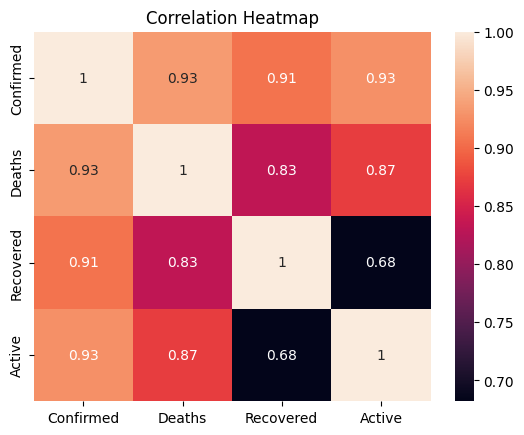

In [19]:
corr = data[["Confirmed", "Deaths", "Recovered", "Active"]].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [20]:
if "Date" in data.columns:
    trend = data.groupby("Date")["Confirmed"].sum()

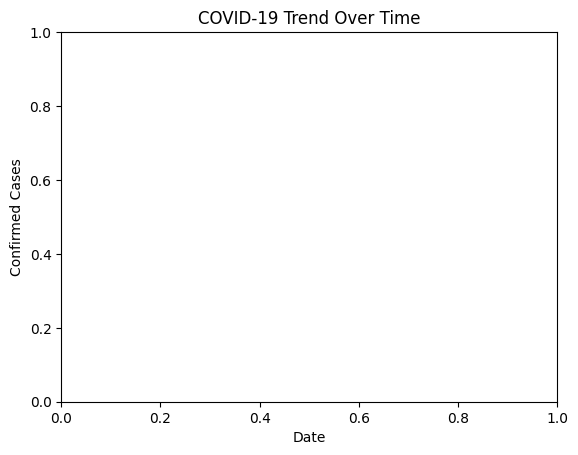

In [22]:
plt.figure()
plt.title("COVID-19 Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

In [23]:
print("\nAnalysis Completed Successfully!")


Analysis Completed Successfully!
